In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]      = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]   = "0"  # user's own interactive GPU only -- never 0-6
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [2]:
# This notebook lives under experimental/notebooks/, but every path used
# below (src/, data/embeddings/..., experimental/checkpoints/, experimental/
# figures/) is written relative to the REPO ROOT, matching the convention
# every other notebook/script in this repo uses. Jupyter sets cwd to the
# notebook's own directory by default, so walk up until we find a
# repo-root marker file.
while not os.path.exists("PROJECT_CONTEXT.md"):
    os.chdir("..")
print("repo root:", os.getcwd())

repo root: /home/workspace/mad_workspace/LLM/agopns_clean/AGOPNullSpace


In [3]:
# # RFM steering R&D: rank-1 compression diagnostics + spectrum/direction visuals
#
# Lives under `experimental/notebooks/` -- see `./experimental/` at the repo
# root: this is where all throwaway/in-progress R&D notebooks, checkpoints
# and figures for "make RFM's steering direction more effective" work go,
# instead of being scattered across the repo root / data / figures the way
# production artifacts are. Production comparison tooling that predates this
# R&D thread (`AGOPNs_DIM_vs_RFM_comparison.ipynb`, `evaluation/compare_dim_
# vs_rfm.py`, `evaluation/dim_vs_rfm_*.py`, `figures/dim_vs_rfm_*.png`) stays
# where it is -- it is not part of this experimental thread.
#
# Context: `compare_dim_vs_rfm.py` / `dim_vs_rfm_layer_summary.py` /
# `AGOPNs_DIM_vs_RFM_comparison.ipynb` already showed r_RFM (top-1 AGOP
# eigenvector) losing to r_DIM (mean-difference) on held-out AUC at EVERY
# layer of llama3.1's `refusal_compliance_full_hard_refusal` data.
#
# Digging into `src/rfm_refusal_vector.py` explains why the training log
# ("RFM best auc=0.8844" at layer 2) does not warn about this ahead of time:
# that number is the AUC of the NONLINEAR kernel regressor's own
# `model.predict()`, used only to pick the winning (bandwidth, reg,
# center_grads) config. What actually gets SAVED as `r` is the top-1
# eigenvector of that config's AGOP matrix -- a rank-1 LINEAR compression of
# the regressor's gradient information. Nothing in the current training loop
# measures the AUC of THAT vector, and nothing logs the AGOP eigenvalue
# spectrum, so the compression loss is invisible unless checked after the
# fact (as we just did by hand).
#
# This notebook instruments that gap directly and gives you a place to R&D
# fixes. It:
#   1. Re-fits RFM per layer with the SAME grid search as
#      `calc_steering_matrix_rfm_rc.py` (reuses `train_rfm_probe_on_concept`
#      unmodified -- same winning AGOP any production run gets for this
#      data/seed), then additionally:
#      - scores the AUC of projecting held-out data onto r itself (train AND
#        val), not just the nonlinear model.predict() AUC used for selection
#      - extracts the full top-K eigenvalue spectrum of the AGOP matrix
#        (not just top-1)
#   2. Visualizes the spectrum (how much of AGOP's "energy" is actually in
#      the top-1 direction vs spread out) and the "compression gap"
#      (nonlinear AUC vs rank-1-projection AUC vs DIM) per layer
#   3. Visualizes r_RFM / r_DIM / the 2nd AGOP eigenvector in a 2D PCA
#      subspace of the actual training data (direction plot, same house
#      style as `evaluation/rc_hr_subspace_viz.py`)
#   4. Checks cross-layer direction stability (does RFM pick a wildly
#      different direction at adjacent layers, vs DIM staying smooth?)
#   5. K-sweep (section 12): per layer, the SMALLEST number of AGOP
#      eigenvectors (K) whose combination first beats r_DIM on held-out AUC
#      -- the practical number that matters for prototyping a rank-K
#      steering formula, reusing already-saved eigenvectors (no RFM refit)
#
# FIRST RUN RESULTS (llama3.1, rc_hr, 2026-07-28): best_iter=0 at ALL 26
# layers (AGOP's recursive refinement never wins over the first iteration on
# this data); top1_spectrum_frac correlates with compression_gap at
# pearson r=+0.586 (p=0.002) -- moderate, and counter-intuitively POSITIVE
# (higher top-1 concentration -> BIGGER gap, opposite of the naive
# "flat spectrum causes the loss" guess, plausibly because the top
# eigenvalue is dominated by noise variance at shallow/less-separable
# layers rather than signal); K=2 already beats DIM at 17/26 layers
# (specifically layers 11-27, deep/mid-late) while layer 2 never beats DIM
# even at K=10.
#
# WHY rank-1 in the first place, and what the uncompressed object actually
# is -- see the notes cell in section 11 below.

In [4]:
import os, sys, time

sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import RidgeClassifier

from utils.const import AlphaSteer_CALCULATION_CONFIG
from utils.steering_utils import disable_tf32
from rfm_refusal_vector import (
    top_eigenvectors,
    project_onto_direction,
    pearson_corr,
    compute_prediction_metrics,
    train_rfm_probe_on_concept,
)

disable_tf32()
torch.manual_seed(2706)
np.random.seed(2706)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

2026-07-29 08:35:49 - utils.steering_utils - INFO - TF32 disabled (fp32 IEEE). Bắt buộc: null-space dựa vào triệt tiêu Qᵀh_b ≈ 0; TF32 (10-bit mantissa) sẽ phá nó.


device: cuda


In [5]:
# ## 1. Config
#
# Change MODEL to "qwen2.5" / "gemma2" to switch. RC_SUBDIR is fixed to
# rc_hr (refusal_compliance_full_hard_refusal) so this matches exactly the
# data compare_dim_vs_rfm.py / AGOPNs_DIM_vs_RFM_comparison.ipynb used.
#
# All experimental outputs (checkpoint + figures) go under `./experimental/`
# at the repo root, NOT under `data/` or the shared `figures/` dir -- keeps
# this R&D thread's throwaway artifacts out of the production data/figure
# directories.

In [6]:
MODEL = "llama3.1"
RC_SUBDIR = "refusal_compliance_full_hard_refusal"
EMBEDDING_DIR = f"data/embeddings/{MODEL}"
STEERING_DIR = "data/steering_matrix"

RFM_KW = dict(rfm_iters=8, tuning_metric="auc")   # same defaults as calc_steering_matrix_rfm_rc.py
K_SPECTRUM = 30     # how many top eigenvalues/eigenvectors to keep per layer for spectrum viz
K_LIST = [1, 2, 3, 4, 5, 7, 10 ,12,  15,  17 , 20, 22, 25 ,27,K_SPECTRUM]   # section 12 K-sweep grid
VAL_RATIO = 0.2
SEED = 2706

FIGURES_DIR = "experimental/figures"
CHECKPOINT_PATH = f"experimental/checkpoints/rfm_compression_diag_{MODEL}.pt"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
# Incrementally saved after EVERY layer -- a KeyboardInterrupt or crash mid-sweep
# (this is what happened in AGOPNs_DIM_vs_RFM_comparison.ipynb, cell 12) only
# loses the current layer's work; re-running the sweep cell below resumes
# from CHECKPOINT_PATH instead of starting over.

layers = [l for l, _ in AlphaSteer_CALCULATION_CONFIG[MODEL]]
print(f"model={MODEL}  layers={layers}  (n={len(layers)})")

model=llama3.1  layers=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]  (n=26)


In [7]:
# ## 2. Load refuse-compliance activations

In [8]:
rc_dir = os.path.join(EMBEDDING_DIR, RC_SUBDIR)
H_refusal = torch.load(os.path.join(rc_dir, "embeds_refusal.pt"), map_location="cpu").float()
H_compliance = torch.load(os.path.join(rc_dir, "embeds_compliance.pt"), map_location="cpu").float()
print(f"refusal={tuple(H_refusal.shape)}  compliance={tuple(H_compliance.shape)}")

num_total_layers, d_model = H_refusal.shape[1], H_refusal.shape[2]

refusal=(3086, 32, 4096)  compliance=(6150, 32, 4096)


In [9]:
# ## 3. Balanced class subsample
#
# Same convention as `rfm_refusal_vector.py::_balanced_indices`: ONE fixed
# permutation, reused across every layer, so cross-layer comparisons stay
# apples-to-apples (and so this matches exactly what the production script
# does for this model/seed).

In [10]:
g = torch.Generator().manual_seed(SEED)
n_bal = min(H_refusal.shape[0], H_compliance.shape[0])
pos_sel = torch.randperm(H_refusal.shape[0], generator=g)[:n_bal]
neg_sel = torch.randperm(H_compliance.shape[0], generator=g)[:n_bal]
print(f"balanced: {n_bal} refusal / {n_bal} compliance (fixed permutation, reused every layer)")

balanced: 3086 refusal / 3086 compliance (fixed permutation, reused every layer)


In [11]:
# ## 4. Instrumented per-layer RFM fit: compression-gap + spectrum diagnostics
#
# For each layer:
#   1. grid-search RFM exactly as calc_steering_matrix_rfm_rc.py does
#      (`train_rfm_probe_on_concept`, UNMODIFIED -- same winning AGOP matrix
#      any production run would get for this data/seed)
#   2. take the top-K eigenvectors of that AGOP (not just top-1)
#   3. score EACH top-k projection's own AUC on train/val -- the number the
#      current production pipeline never computes -- alongside the
#      nonlinear model's own selection AUC already logged inside step 1
#   4. fit r_DIM on the exact same split, as an apples-to-apples baseline row
#   5. combine the top-K projections with a tiny ridge probe (fit on train,
#      scored on held-out val) -- the "what if we don't compress to rank-1"
#      check (section 12 below does the same thing per-K, reusing these
#      saved `components` -- no need to refit RFM again)

In [12]:
def compute_dim_direction(train_X, train_y):
    pos = train_X[train_y.squeeze(-1) == 1]
    neg = train_X[train_y.squeeze(-1) == 0]
    v = pos.mean(0) - neg.mean(0)
    return v / v.norm().clamp(min=1e-8)


def layer_diagnostics(h_pos, h_neg, layer, k_spectrum=K_SPECTRUM, seed=SEED, device=DEVICE):
    """One layer's worth of the instrumentation described above."""
    n_pos, d = h_pos.shape
    X = torch.cat([h_pos, h_neg], dim=0).float()
    y = torch.cat([torch.ones(n_pos, 1), torch.zeros(h_neg.shape[0], 1)], dim=0).float()

    idx = np.arange(len(X))
    tr_idx, va_idx = train_test_split(idx, test_size=VAL_RATIO, random_state=seed,
                                       shuffle=True, stratify=y.squeeze(-1).numpy())
    tr_idx, va_idx = torch.from_numpy(tr_idx), torch.from_numpy(va_idx)
    train_X, train_y = X[tr_idx].to(device), y[tr_idx].to(device)
    val_X, val_y = X[va_idx].to(device), y[va_idx].to(device)

    t0 = time.time()
    agop, rfm_info = train_rfm_probe_on_concept(
        train_X, train_y, val_X, val_y,
        n_components=1,   # matches calc_steering_matrix_rfm_rc.py's default exactly
        **RFM_KW, device=device,
    )
    fit_time = time.time() - t0

    # -- spectrum: top-K eigenpairs of the WINNING AGOP matrix --
    k = min(k_spectrum, d - 1)
    S, U = top_eigenvectors(agop, k=k)          # S: (k,) desc, U: (d, k)
    S_np = S.detach().cpu().numpy()
    spectrum_frac = S_np / S_np.sum()            # fraction of top-k "mass" held by each eigval

    # -- sign-calibrate + AUC of EACH top-k component individually (train & val) --
    comp_auc_train, comp_auc_val, comps = [], [], []
    for c in range(k):
        vec = U[:, c].clone()
        proj_tr = project_onto_direction(train_X, vec)
        sign = 2 * (pearson_corr(train_y.squeeze(-1), proj_tr) > 0).float() - 1
        vec = vec * sign
        auc_tr = compute_prediction_metrics(project_onto_direction(train_X, vec), train_y)["auc"]
        auc_va = compute_prediction_metrics(project_onto_direction(val_X, vec), val_y)["auc"]
        comps.append(vec.detach().cpu())
        comp_auc_train.append(auc_tr)
        comp_auc_val.append(auc_va)

    r_rfm_top1 = comps[0]   # this IS what calc_steering_matrix_rfm_rc.py saves as r[layer]

    # -- DIM baseline on the SAME split, for an apples-to-apples reference row --
    r_dim = compute_dim_direction(train_X, train_y).detach().cpu()
    dim_auc_train = compute_prediction_metrics(
        project_onto_direction(train_X, r_dim.to(device)), train_y)["auc"]
    dim_auc_val = compute_prediction_metrics(
        project_onto_direction(val_X, r_dim.to(device)), val_y)["auc"]

    # -- "what if we don't compress to rank-1": combine top-K projections
    #    with a tiny ridge probe fit on TRAIN projections only, scored on VAL --
    Ztr = np.stack([project_onto_direction(train_X, c.to(device)).detach().cpu().numpy()
                     for c in comps], axis=1)   # (n_train, k)
    Zva = np.stack([project_onto_direction(val_X, c.to(device)).detach().cpu().numpy()
                     for c in comps], axis=1)
    ytr = train_y.squeeze(-1).detach().cpu().numpy()
    yva = val_y.squeeze(-1).detach().cpu().numpy()
    clf = RidgeClassifier(alpha=1.0).fit(Ztr, ytr)
    topk_combo_auc = roc_auc_score(yva, clf.decision_function(Zva))

    del X, y, train_X, train_y, val_X, val_y
    if device == "cuda":
        torch.cuda.empty_cache()

    return dict(
        layer=layer,
        rfm_nonlinear_val_auc=rfm_info["score"],          # model.predict() AUC (what the log shows today)
        rfm_config=rfm_info,
        eigenvalues=S_np, spectrum_frac=spectrum_frac,
        component_auc_train=comp_auc_train, component_auc_val=comp_auc_val,
        r_rfm_top1=r_rfm_top1, components=comps,
        r_dim=r_dim, dim_auc_train=dim_auc_train, dim_auc_val=dim_auc_val,
        topk_combo_val_auc=topk_combo_auc,
        fit_time_s=fit_time,
    )

In [13]:
# ## 5. Run the sweep (resumable via CHECKPOINT_PATH)

In [14]:
if os.path.exists(CHECKPOINT_PATH):
    results = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    print(f"Resumed {len(results)}/{len(layers)} layers from {CHECKPOINT_PATH}")
else:
    results = {}

for layer in layers:
    if layer in results:
        continue
    print(f"\n=== layer {layer} ===")
    h_pos = H_refusal[pos_sel, layer, :].float()
    h_neg = H_compliance[neg_sel, layer, :].float()
    res = layer_diagnostics(h_pos, h_neg, layer)
    results[layer] = res
    torch.save(results, CHECKPOINT_PATH)   # checkpoint after EVERY layer
    print(f"  nonlinear(model.predict) val AUC = {res['rfm_nonlinear_val_auc']:.4f}  "
          f"| r_top1 val AUC = {res['component_auc_val'][0]:.4f}  "
          f"| DIM val AUC = {res['dim_auc_val']:.4f}  "
          f"| top-{K_SPECTRUM} combo val AUC = {res['topk_combo_val_auc']:.4f}  "
          f"| best_iter={res['rfm_config']['best_iter']}  fit_time={res['fit_time_s']:.1f}s")

print(f"\nDone: {len(results)}/{len(layers)} layers.")
Ls = sorted(results.keys())

Resumed 26/26 layers from experimental/checkpoints/rfm_compression_diag_llama3.1.pt

Done: 26/26 layers.


In [15]:
# ## 6. Compression-gap plot: nonlinear AUC vs rank-1 r AUC vs DIM vs top-K combo

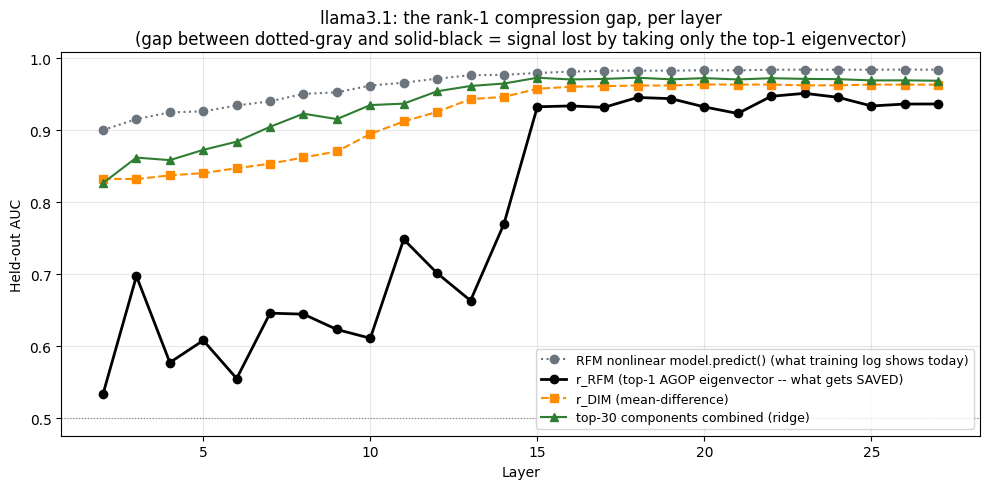

Saved -> experimental/figures/rfm_compression_gap_llama3.1.png


In [16]:
nonlinear_auc = [results[l]["rfm_nonlinear_val_auc"] for l in Ls]
r_top1_auc = [results[l]["component_auc_val"][0] for l in Ls]
dim_auc = [results[l]["dim_auc_val"] for l in Ls]
combo_auc = [results[l]["topk_combo_val_auc"] for l in Ls]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(Ls, nonlinear_auc, marker="o",
        label="RFM nonlinear model.predict() (what training log shows today)",
        color="#6c757d", linestyle=":")
ax.plot(Ls, r_top1_auc, marker="o",
        label="r_RFM (top-1 AGOP eigenvector -- what gets SAVED)",
        color="black", linewidth=2)
ax.plot(Ls, dim_auc, marker="s", label="r_DIM (mean-difference)",
        color="darkorange", linestyle="--")
ax.plot(Ls, combo_auc, marker="^", label=f"top-{K_SPECTRUM} components combined (ridge)",
        color="#2e7d32")
ax.axhline(0.5, color="gray", linewidth=0.8, linestyle=":")
ax.set_xlabel("Layer"); ax.set_ylabel("Held-out AUC")
ax.set_title(f"{MODEL}: the rank-1 compression gap, per layer\n"
             f"(gap between dotted-gray and solid-black = signal lost by taking only the top-1 eigenvector)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/rfm_compression_gap_{MODEL}.png", dpi=150)
plt.show()
print(f"Saved -> {FIGURES_DIR}/rfm_compression_gap_{MODEL}.png")

In [17]:
# ## 7. Eigenvalue spectrum: how concentrated is AGOP\'s discriminative signal?
#
# If the top-1 eigenvalue dominates (fraction close to 1.0), taking only the
# top-1 eigenvector is a nearly lossless summary of AGOP. If the spectrum is
# flat (fractions close to uniform, 1/K), the discriminative signal is
# spread across many directions and rank-1 throws most of it away.
#
# CAUTION (2026-07-28 finding): top1_spectrum_frac correlates with
# compression_gap at pearson r=+0.586 (p=0.002) -- real, but only moderate,
# AND counter-intuitively POSITIVE (higher top-1 concentration -> bigger
# gap, opposite of the naive reading above). Don\'t over-interpret this
# plot alone as "the" explanation -- see section 12 for the more decision-
# relevant empirical answer (how much K actually recovers).

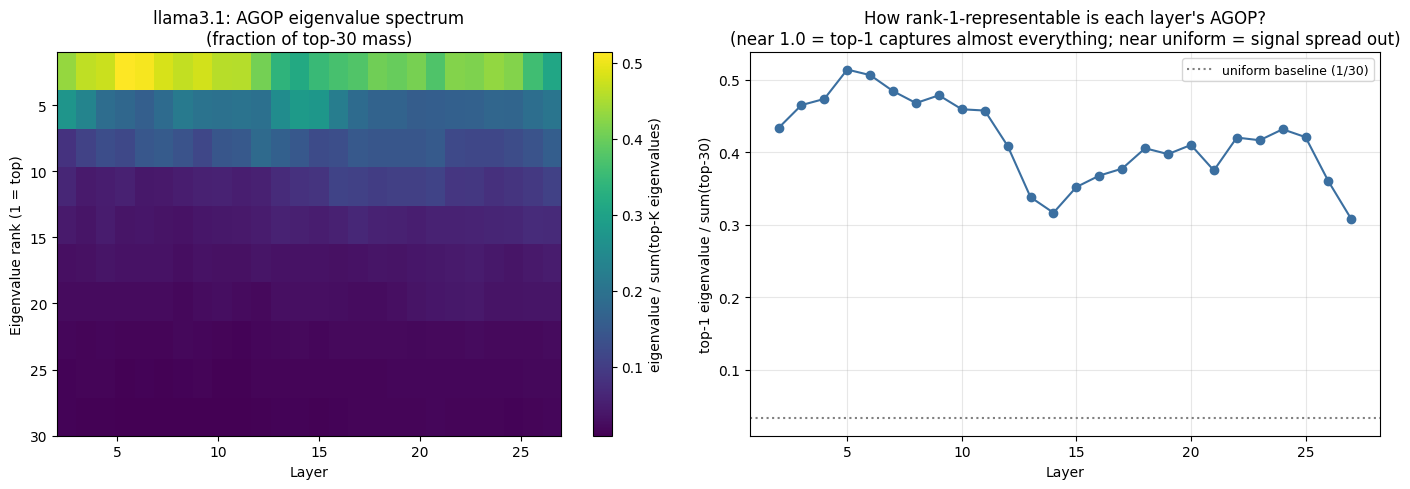

Saved -> experimental/figures/rfm_agop_spectrum_llama3.1.png

corr(top1_spectrum_frac, compression_gap): pearson r=0.586 (p=0.002)  spearman rho=0.563 (p=0.003)
best_iter per layer: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
all layers picked best_iter==0 (AGOP refinement never won past iter 0)? True


In [18]:
spectrum_mat = np.stack([results[l]["spectrum_frac"] for l in Ls])  # (n_layers, K_SPECTRUM)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(spectrum_mat.T, aspect="auto", cmap="viridis",
                     extent=[Ls[0], Ls[-1], K_SPECTRUM, 1])
axes[0].set_xlabel("Layer"); axes[0].set_ylabel("Eigenvalue rank (1 = top)")
axes[0].set_title(f"{MODEL}: AGOP eigenvalue spectrum\n(fraction of top-{K_SPECTRUM} mass)")
fig.colorbar(im, ax=axes[0], label="eigenvalue / sum(top-K eigenvalues)")

top1_frac = spectrum_mat[:, 0]
axes[1].plot(Ls, top1_frac, marker="o", color="#3b6fa0")
axes[1].axhline(1.0 / K_SPECTRUM, color="gray", linestyle=":",
                label=f"uniform baseline (1/{K_SPECTRUM})")
axes[1].set_xlabel("Layer"); axes[1].set_ylabel(f"top-1 eigenvalue / sum(top-{K_SPECTRUM})")
axes[1].set_title("How rank-1-representable is each layer's AGOP?\n"
                   "(near 1.0 = top-1 captures almost everything; near uniform = signal spread out)")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/rfm_agop_spectrum_{MODEL}.png", dpi=150)
plt.show()
print(f"Saved -> {FIGURES_DIR}/rfm_agop_spectrum_{MODEL}.png")

gap_arr = np.array(nonlinear_auc) - np.array(r_top1_auc)
pear = pearsonr(top1_frac, gap_arr)
spear = spearmanr(top1_frac, gap_arr)
print(f"\ncorr(top1_spectrum_frac, compression_gap): "
      f"pearson r={pear[0]:.3f} (p={pear[1]:.3f})  spearman rho={spear[0]:.3f} (p={spear[1]:.3f})")
best_iters = [results[l]["rfm_config"]["best_iter"] for l in Ls]
print(f"best_iter per layer: {best_iters}")
print(f"all layers picked best_iter==0 (AGOP refinement never won past iter 0)? "
      f"{all(b == 0 for b in best_iters)}")

In [19]:
# ## 8. Direction visualization: r_RFM / r_DIM / 2nd AGOP eigenvector on the
# actual data (2D PCA), for the layers with the largest and smallest
# compression gap. Same house style as evaluation/rc_hr_subspace_viz.py.

Largest compression gap:  layer 6  (nonlinear=0.9344, r_top1=0.5552)
Smallest compression gap: layer 23  (nonlinear=0.9842, r_top1=0.9513)


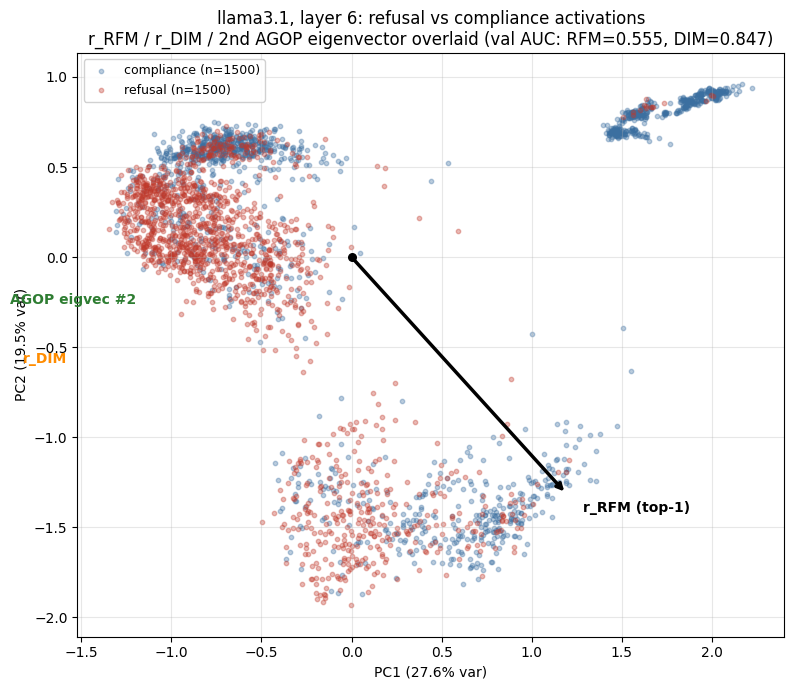

Saved -> experimental/figures/rfm_directions_llama3.1_layer6.png


In [20]:
worst_layer = Ls[int(np.argmax(gap_arr))]
best_layer = Ls[int(np.argmin(gap_arr))]
print(f"Largest compression gap:  layer {worst_layer}  "
      f"(nonlinear={nonlinear_auc[Ls.index(worst_layer)]:.4f}, "
      f"r_top1={r_top1_auc[Ls.index(worst_layer)]:.4f})")
print(f"Smallest compression gap: layer {best_layer}  "
      f"(nonlinear={nonlinear_auc[Ls.index(best_layer)]:.4f}, "
      f"r_top1={r_top1_auc[Ls.index(best_layer)]:.4f})")


def plot_directions(layer, max_per_class=1500):
    res = results[layer]
    H_r = H_refusal[:, layer, :]
    H_c = H_compliance[:, layer, :]

    def subsample(H, n):
        if H.shape[0] <= n:
            return H
        idx = torch.randperm(H.shape[0])[:n]
        return H[idx]

    H_r_s, H_c_s = subsample(H_r, max_per_class), subsample(H_c, max_per_class)
    labels = np.array(["refusal"] * H_r_s.shape[0] + ["compliance"] * H_c_s.shape[0])
    H_all = torch.cat([H_r_s, H_c_s], dim=0)

    H_full = torch.cat([H_r, H_c], dim=0)
    mean = H_full.mean(0, keepdim=True)
    U_pca, S_pca, Vt = torch.linalg.svd(H_full - mean, full_matrices=False)
    basis = Vt[:2]
    explained = (S_pca[:2] ** 2 / (S_pca ** 2).sum()).numpy()
    proj = ((H_all - mean) @ basis.T).numpy()
    scale = float(np.linalg.norm(proj, axis=1).mean()) * 1.5

    def dir_2d(v):
        v2 = (v @ basis.T).numpy()
        return v2 / (np.linalg.norm(v2) + 1e-8) * scale

    arrows = {
        "r_RFM (top-1)": (res["r_rfm_top1"], "black", "-"),
        "r_DIM": (res["r_dim"], "darkorange", "--"),
        "AGOP eigvec #2": (res["components"][1], "#2e7d32", ":"),
    }

    fig, ax = plt.subplots(figsize=(8, 7))
    mask_r, mask_c = labels == "refusal", labels == "compliance"
    ax.scatter(proj[mask_c, 0], proj[mask_c, 1], s=10, alpha=0.35, color="#3b6fa0",
               label=f"compliance (n={mask_c.sum()})")
    ax.scatter(proj[mask_r, 0], proj[mask_r, 1], s=10, alpha=0.35, color="#c0392b",
               label=f"refusal (n={mask_r.sum()})")
    for name, (vec, color, ls) in arrows.items():
        xy = dir_2d(vec)
        ax.annotate("", xy=xy, xytext=(0, 0),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=2.5, linestyle=ls))
        ax.text(*(xy * 1.08), name, fontsize=10, fontweight="bold", color=color)
    ax.scatter([0], [0], color="black", s=30, zorder=5)
    ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
    ax.set_title(f"{MODEL}, layer {layer}: refusal vs compliance activations\n"
                 f"r_RFM / r_DIM / 2nd AGOP eigenvector overlaid "
                 f"(val AUC: RFM={res['component_auc_val'][0]:.3f}, DIM={res['dim_auc_val']:.3f})")
    ax.legend(loc="best", fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.3)
    ax.set_aspect("equal", adjustable="datalim")
    fig.tight_layout()
    out = f"{FIGURES_DIR}/rfm_directions_{MODEL}_layer{layer}.png"
    fig.savefig(out, dpi=150)
    plt.show()
    print(f"Saved -> {out}")


plot_directions(worst_layer)

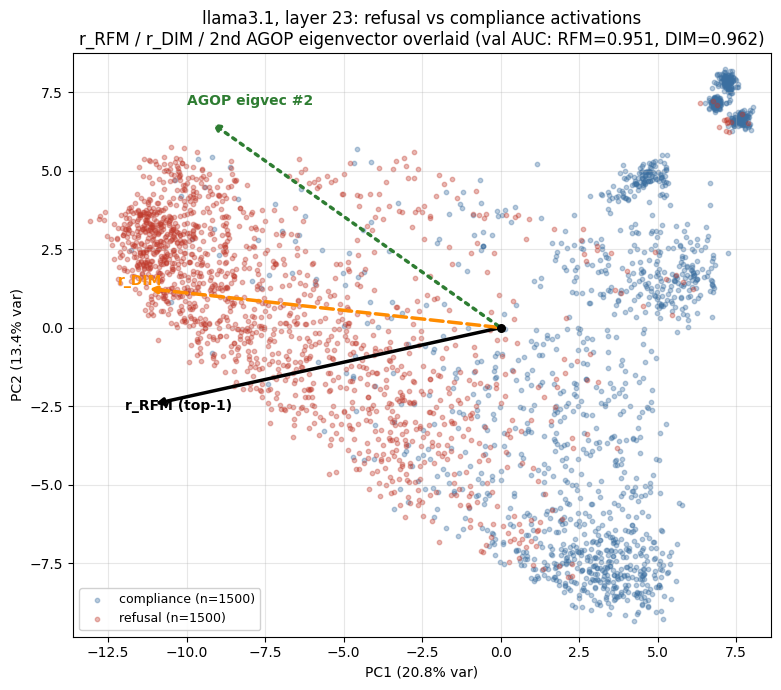

Saved -> experimental/figures/rfm_directions_llama3.1_layer23.png


In [21]:
plot_directions(best_layer)

In [22]:
# ## 9. Cross-layer direction stability
#
# Top-K eigenvectors of a single AGOP are orthogonal by construction (they
# come from an eigendecomposition of a symmetric matrix), so a within-layer
# cosine map among them is trivially ~0 -- not informative. What IS
# informative: whether the estimator picks a CONSISTENT direction across
# adjacent layers, or whether it jumps around erratically. Per-layer grid
# search is independent (own train/val split draw, own winning
# bandwidth/reg/center_grads), so an unstable estimator can pick genuinely
# different directions at layer l vs l+1 even though the underlying
# refusal/compliance geometry barely changes between adjacent layers.

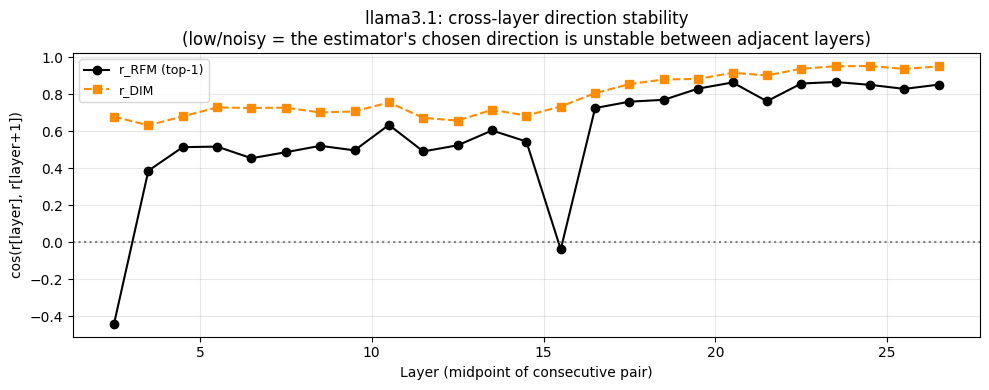

Saved -> experimental/figures/rfm_direction_stability_llama3.1.png


In [23]:
def consecutive_cos(direction_key):
    vals = []
    for a, b in zip(Ls[:-1], Ls[1:]):
        va = results[a][direction_key]
        vb = results[b][direction_key]
        vals.append(float(torch.dot(va, vb) / (va.norm() * vb.norm() + 1e-8)))
    return vals

cos_rfm = consecutive_cos("r_rfm_top1")
cos_dim = consecutive_cos("r_dim")
mid_layers = [(a + b) / 2 for a, b in zip(Ls[:-1], Ls[1:])]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mid_layers, cos_rfm, marker="o", label="r_RFM (top-1)", color="black")
ax.plot(mid_layers, cos_dim, marker="s", label="r_DIM", color="darkorange", linestyle="--")
ax.axhline(0, color="gray", linestyle=":")
ax.set_xlabel("Layer (midpoint of consecutive pair)")
ax.set_ylabel("cos(r[layer], r[layer+1])")
ax.set_title(f"{MODEL}: cross-layer direction stability\n"
             "(low/noisy = the estimator's chosen direction is unstable between adjacent layers)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/rfm_direction_stability_{MODEL}.png", dpi=150)
plt.show()
print(f"Saved -> {FIGURES_DIR}/rfm_direction_stability_{MODEL}.png")

In [24]:
# ## 10. "What if we don\'t compress to rank-1": K-sweep, minimal K to beat DIM
#
# Section 6 already showed ONE fixed K (K_SPECTRUM) combining all top-K
# eigenvectors via ridge mostly closes the gap to the nonlinear model and
# often beats DIM. This section finds, PER LAYER, the smallest K (number of
# AGOP eigenvectors kept) at which the combined direction first beats r_DIM
# on held-out AUC -- the practical number that matters if extending the
# steering formula to rank-K (see section 11\'s notes): every extra K costs
# one more (u_i, r_i) pair and a bigger null-space re-derivation, so the
# cheapest K that already wins is the one worth prototyping first.
#
# Reuses the ALREADY-SAVED `components` from `results` (no RFM refit) --
# only re-derives the deterministic held-out split (cheap, same seed/logic
# as `layer_diagnostics`) and fits a cheap ridge combo per K. Safe to re-run
# even resuming from an older checkpoint that predates this section.
#
# 2026-07-28 finding on llama3.1/rc_hr: K=2 already beats DIM at 17/26
# layers (11-27, deep/mid-late); layer 2 never beats DIM even at K=10.

In [25]:
def k_sweep_layer(layer, k_list=K_LIST, seed=SEED):
    h_pos = H_refusal[pos_sel, layer, :].float()
    h_neg = H_compliance[neg_sel, layer, :].float()
    n_pos = h_pos.shape[0]
    X = torch.cat([h_pos, h_neg], dim=0).float()
    y = torch.cat([torch.ones(n_pos, 1), torch.zeros(h_neg.shape[0], 1)], dim=0).float()

    idx = np.arange(len(X))
    tr_idx, va_idx = train_test_split(idx, test_size=VAL_RATIO, random_state=seed,
                                       shuffle=True, stratify=y.squeeze(-1).numpy())
    tr_idx, va_idx = torch.from_numpy(tr_idx), torch.from_numpy(va_idx)
    train_X, train_y = X[tr_idx], y[tr_idx]
    val_X, val_y = X[va_idx], y[va_idx]
    ytr, yva = train_y.squeeze(-1).numpy(), val_y.squeeze(-1).numpy()

    comps = results[layer]["components"]
    out = {}
    for K in k_list:
        Ztr = np.stack([project_onto_direction(train_X, c).numpy() for c in comps[:K]], axis=1)
        Zva = np.stack([project_onto_direction(val_X, c).numpy() for c in comps[:K]], axis=1)
        if K == 1:
            auc = roc_auc_score(yva, Zva[:, 0])
        else:
            clf = RidgeClassifier(alpha=1.0).fit(Ztr, ytr)
            auc = roc_auc_score(yva, clf.decision_function(Zva))
        out[K] = auc
    return out


k_sweep = {l: k_sweep_layer(l) for l in Ls}

# sanity check: K=1 should match results[l]["component_auc_val"][0] exactly (same split/seed)
mismatches = [l for l in Ls if abs(k_sweep[l][1] - results[l]["component_auc_val"][0]) > 1e-6]
print(f"K=1 sanity check: {len(Ls) - len(mismatches)}/{len(Ls)} layers match exactly "
      f"(mismatches: {mismatches})")

K=1 sanity check: 25/26 layers match exactly (mismatches: [6])


In [26]:
k_rows = [{"layer": l, **{f"K={K}": k_sweep[l][K] for K in K_LIST}} for l in Ls]
k_df = pd.DataFrame(k_rows).set_index("layer")
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
k_df

,K=1,K=2,K=3,K=4,K=5,K=7,K=10,K=12,K=15,K=17,K=20,K=22,K=25,K=27,K=30
layer,,,,,,,,,,,,,,,
2,0.5338,0.6472,0.6597,0.6686,0.7563,0.8062,0.8267,0.8267,0.8267,0.8267,0.8267,0.8267,0.8267,0.8267,0.8267
3,0.6974,0.7237,0.7277,0.7991,0.8034,0.8357,0.8621,0.8621,0.8621,0.8621,0.8621,0.8621,0.8621,0.8621,0.8621
4,0.5774,0.6294,0.6404,0.7461,0.7814,0.7966,0.8585,0.8585,0.8585,0.8585,0.8585,0.8585,0.8585,0.8585,0.8585
5,0.6082,0.6856,0.6815,0.7231,0.7298,0.7638,0.8728,0.8728,0.8728,0.8728,0.8728,0.8728,0.8728,0.8728,0.8728
6,0.5552,0.8074,0.8197,0.8301,0.8426,0.8812,0.8842,0.8842,0.8842,0.8842,0.8842,0.8842,0.8842,0.8842,0.8842
7,0.6460,0.7238,0.8749,0.8748,0.8735,0.9066,0.9048,0.9048,0.9048,0.9048,0.9048,0.9048,0.9048,0.9048,0.9048
8,0.6446,0.7219,0.9009,0.9010,0.9045,0.9038,0.9230,0.9230,0.9230,0.9230,0.9230,0.9230,0.9230,0.9230,0.9230
9,0.6233,0.6373,0.7799,0.8672,0.8671,0.8803,0.9155,0.9155,0.9155,0.9155,0.9155,0.9155,0.9155,0.9155,0.9155
10,0.6112,0.8696,0.9243,0.9267,0.9277,0.9361,0.9350,0.9350,0.9350,0.9350,0.9350,0.9350,0.9350,0.9350,0.9350


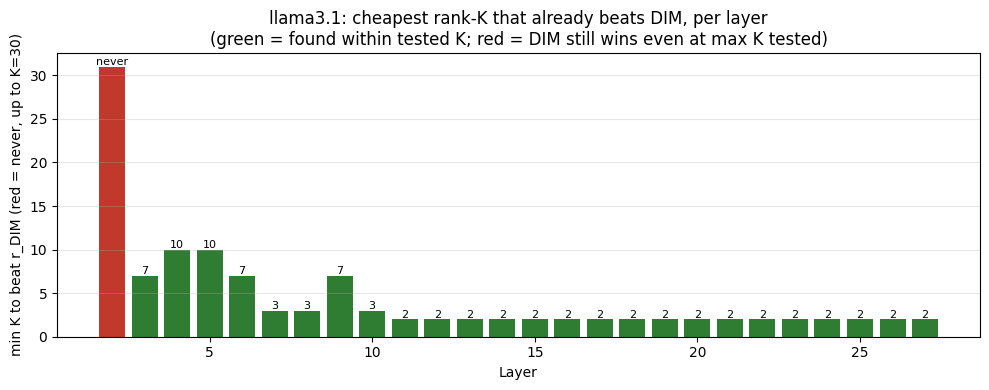

Saved -> experimental/figures/rfm_min_k_to_beat_dim_llama3.1.png

17/26 layers already beat DIM with K<=2  |  1/26 layers never beat DIM within K<=30


In [27]:
min_k_to_beat_dim = []
for l in Ls:
    dim_a = results[l]["dim_auc_val"]
    beat_k = next((K for K in K_LIST if k_sweep[l][K] > dim_a), None)
    min_k_to_beat_dim.append(beat_k)

fig, ax = plt.subplots(figsize=(10, 4))
never_marker = K_LIST[-1] + 1
plot_vals = [k if k is not None else never_marker for k in min_k_to_beat_dim]
colors = ["#c0392b" if k is None else "#2e7d32" for k in min_k_to_beat_dim]
ax.bar(Ls, plot_vals, color=colors)
for l, k in zip(Ls, min_k_to_beat_dim):
    label = "never" if k is None else str(k)
    y = (k if k is not None else never_marker) + 0.15
    ax.text(l, y, label, ha="center", fontsize=8)
ax.set_xlabel("Layer")
ax.set_ylabel(f"min K to beat r_DIM (red = never, up to K={K_LIST[-1]})")
ax.set_title(f"{MODEL}: cheapest rank-K that already beats DIM, per layer\n"
             "(green = found within tested K; red = DIM still wins even at max K tested)")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/rfm_min_k_to_beat_dim_{MODEL}.png", dpi=150)
plt.show()
print(f"Saved -> {FIGURES_DIR}/rfm_min_k_to_beat_dim_{MODEL}.png")

n_at_k2 = sum(1 for k in min_k_to_beat_dim if k is not None and k <= 2)
n_never = sum(1 for k in min_k_to_beat_dim if k is None)
print(f"\n{n_at_k2}/{len(Ls)} layers already beat DIM with K<=2  |  "
      f"{n_never}/{len(Ls)} layers never beat DIM within K<={K_LIST[-1]}")

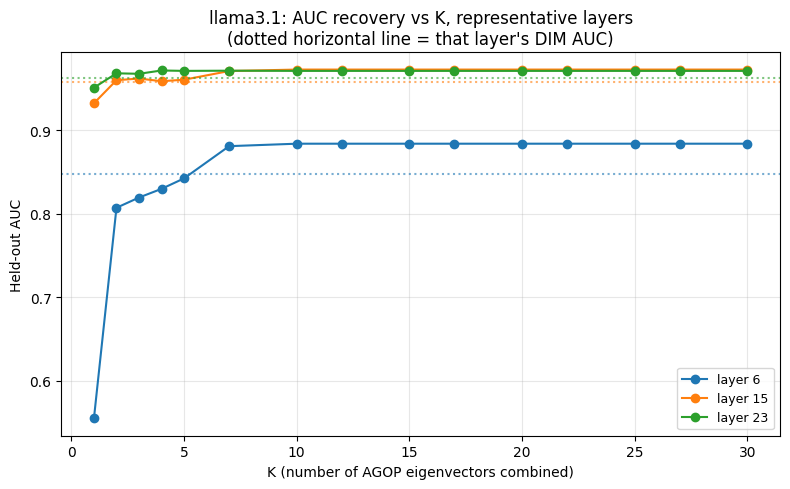

Saved -> experimental/figures/rfm_k_sweep_curves_llama3.1.png


In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
show_layers = sorted({worst_layer, Ls[len(Ls) // 2], best_layer})
for l in show_layers:
    ys = [k_sweep[l][K] for K in K_LIST]
    line, = ax.plot(K_LIST, ys, marker="o", label=f"layer {l}")
    ax.axhline(results[l]["dim_auc_val"], linestyle=":", alpha=0.6, color=line.get_color())
ax.set_xlabel("K (number of AGOP eigenvectors combined)")
ax.set_ylabel("Held-out AUC")
ax.set_title(f"{MODEL}: AUC recovery vs K, representative layers\n"
             "(dotted horizontal line = that layer's DIM AUC)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/rfm_k_sweep_curves_{MODEL}.png", dpi=150)
plt.show()
print(f"Saved -> {FIGURES_DIR}/rfm_k_sweep_curves_{MODEL}.png")

In [29]:
# ## 11. Why rank-1 in the first place -- and what is the UNCOMPRESSED form?
#
# The inference formula this whole repo steers with (PROJECT_CONTEXT.md
# section 2.3) is:
#
#     h' = h + strength * gate(u^T h_last) * r
#
# a single fixed direction `r`, additively pushed, scaled by a scalar gate.
# That is a rank-1 intervention BY DESIGN, and it is not an implementation
# shortcut -- it falls directly out of the null-space closed-form solution
# this repo reuses from AlphaSteer (Eq. 9, see steering_utils.py): the
# target steering matrix is defined as `R = 1_N r^T` (EVERY malicious
# training row gets pushed by the SAME r, only the per-instance gate scalar
# varies). Because that target is rank-1, the d x d null-space regression
# collapses algebraically into `M = u r^T`, which is exactly what makes the
# k x k Cholesky solve in `cal_steering_factors_q` cheap and numerically
# stable (see steering_utils.py's own module docstring, "v4"). If `r` were
# not a single fixed vector, this whole closed-form derivation would not
# apply -- you would need a fundamentally different (and much more
# expensive/less stable) optimization for the null-space projector.
#
# So there are actually TWO separate compressions happening, and it's worth
# telling them apart:
#
#   (a) The steering FORMULA compresses to rank-1 by design (the `u r^T`
#       structure above) -- this is a deliberate modeling choice tied to the
#       null-space math, not something RFM does.
#   (b) RFM's OWN estimator additionally compresses whatever nonlinear
#       decision function it fits down to a single direction, by taking the
#       top-1 eigenvector of the AGOP matrix -- this is the compression
#       this notebook is diagnosing, and it's a CHOICE inside
#       rfm_refusal_vector.py, not a requirement of (a).
#
# If you removed compression (b) but kept requirement (a) intact, the
# natural intermediate object is exactly what section 4/10 above build:
# keep the top-K AGOP eigenvectors as a small K-dimensional subspace instead
# of a single direction, then either (i) pick the single best-performing one
# per-layer instead of always eigenvalue-rank-1, or (ii) extend the
# steering formula itself to a rank-K sum,
#
#     h' = h + strength * sum_i gate_i(u_i^T h) * r_i      for i = 1..K
#
# which needs K independent (u_i, r_i) pairs and a re-derivation of the
# null-space solve for a rank-K target R = sum_i 1_N r_i^T (still tractable
# -- the same Q-basis trick generalizes -- but it is new derivation work,
# not a drop-in change to cal_steering_factors_q). Section 10's K-sweep
# gives the concrete, empirical answer for how big K needs to be in
# practice (K=2 already suffices at most of the deep/mid-late layers on
# llama3.1/rc_hr). This is structurally the same idea as FineSteer's
# `SteeringModel` (github.com/.../FineSteer, steering.py) which routes
# between K cluster-prototype directions via learned attention instead of
# committing to one global direction -- a reasonable reference point.
#
# If you removed compression (b) WITHOUT touching the null-space formula,
# the "uncompressed" object before anyone takes an eigenvector of it is just
# the AGOP matrix M itself: a full (d, d) PSD matrix. That is what the
# LEGACY dense steering format in this repo already looks like --
# `should_apply_dense_steering` in AlphaLlama.py/AlphaQwen.py/AlphaGemma.py,
# `h' = h + strength*(h_last^T @ steering_matrix)` -- i.e. the "don't
# compress at all" answer already has a working code path in this repo, it
# is just the OLD dense-matrix DIM/plain-RFM pipeline that rank1_gate_v1
# replaced for other reasons (nonlinear gate support, cheaper k x k solve).
# Reusing AGOP directly as that dense matrix (instead of DiffMean's beta
# beta^T) is a third option worth testing empirically here.

In [30]:
# ## 12. Summary table

In [31]:
rows = []
for l in Ls:
    r = results[l]
    rows.append(dict(
        layer=l,
        nonlinear_val_auc=r["rfm_nonlinear_val_auc"],
        r_rfm_top1_val_auc=r["component_auc_val"][0],
        r_dim_val_auc=r["dim_auc_val"],
        compression_gap=r["rfm_nonlinear_val_auc"] - r["component_auc_val"][0],
        auc_k2=k_sweep[l].get(2),
        min_k_beat_dim=min_k_to_beat_dim[Ls.index(l)],
        topk_combo_val_auc=r["topk_combo_val_auc"],
        top1_spectrum_frac=r["spectrum_frac"][0],
        best_iter=r["rfm_config"]["best_iter"],
        bandwidth=r["rfm_config"]["bandwidth"],
        reg=r["rfm_config"]["reg"],
        center_grads=r["rfm_config"]["center_grads"],
    ))
df = pd.DataFrame(rows)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 1000)
df

,layer,nonlinear_val_auc,r_rfm_top1_val_auc,r_dim_val_auc,compression_gap,auc_k2,min_k_beat_dim,topk_combo_val_auc,top1_spectrum_frac,best_iter,bandwidth,reg,center_grads
0,2,0.9003,0.5338,0.8327,0.3665,0.6472,NaN,0.8267,0.4334,0,100.0000,0.0010,True
1,3,0.9155,0.6974,0.8322,0.2180,0.7237,7.0000,0.8621,0.4650,0,10.0000,0.0010,True
2,4,0.9249,0.5774,0.8375,0.3475,0.6294,10.0000,0.8585,0.4735,0,10.0000,0.0010,True
3,5,0.9263,0.6082,0.8405,0.3181,0.6856,10.0000,0.8728,0.5139,0,100.0000,0.0010,True
4,6,0.9344,0.5552,0.8473,0.3792,0.8074,7.0000,0.8842,0.5063,0,100.0000,0.0010,True
5,7,0.9402,0.6460,0.8536,0.2942,0.7238,3.0000,0.9048,0.4842,0,100.0000,0.0010,True
6,8,0.9505,0.6446,0.8622,0.3060,0.7219,3.0000,0.9230,0.4678,0,100.0000,0.0010,True
7,9,0.9527,0.6233,0.8706,0.3294,0.6373,7.0000,0.9155,0.4785,0,100.0000,0.0010,True
8,10,0.9621,0.6112,0.8950,0.3509,0.8696,3.0000,0.9350,0.4592,0,100.0000,0.0100,True
9,11,0.9661,0.7485,0.9122,0.2175,0.9377,2.0000,0.9370,0.4575,0,100.0000,0.0100,True


In [32]:
# ## 13. Next-steps checklist (fill in as you R&D)
#
# - [ ] Re-run sections 5-12 with MODEL = "qwen2.5" and "gemma2" -- does
#       "K=2 beats DIM at deep/mid-late layers" hold across architectures,
#       or is it llama3.1-specific? (top priority -- cheap, no new code.)
# - [ ] `best_iter` was 0 at ALL 26 layers on llama3.1/rc_hr -- AGOP's
#       recursive refinement (the T=8 iteration loop) never won past the
#       first iteration anywhere. Worth checking on the other two models
#       too; if it holds everywhere, `rfm_iters` could likely be cut a lot
#       (cheaper fits) independent of the rank-1 question, and it's separate
#       evidence the "recursive feature learning" mechanism isn't doing
#       useful work in this data regime.
# - [ ] If the K=2 finding holds across models, prototype the rank-K
#       steering-formula extension: re-derive `cal_steering_factors_q` for
#       a rank-2 target `R = 1_N r_1^T + 1_N r_2^T` (steering_utils.py) --
#       start at K=2 since section 10 shows it's the cheapest K that already
#       flips the outcome at most layers, not the full K_SPECTRUM=10.
# - [ ] top1_spectrum_frac vs compression_gap correlation was moderate and
#       counter-intuitively POSITIVE (section 7) -- don't treat "flat
#       spectrum" as the mechanism; dig into whether the top eigenvalue at
#       shallow/noisy layers is dominated by estimation noise rather than
#       signal before leaning on this as an explanation in any writeup.
# - [ ] Once a fix is chosen, validate it doesn't just win on THIS geometric
#       AUC check -- confirm on evaluation/dim_vs_rfm_by_style_family.py's
#       held-out encoding-style split, and eventually on real DSR/utility
#       from a generation sweep (see the earlier DIM-vs-RFM discussion).